Setup

In [9]:
df = pd.read_csv("bank-additional-full.csv", sep=';')

print("Shape:", df.shape)
df.head()

Shape: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


EDA

In [10]:
# Overview: data types, nulls, feature classification
print("=== Dataset Info ===")
df.info()

numeric_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = df.select_dtypes(include=['object']).columns.tolist()

print(f"\nNumeric features ({len(numeric_features)}): {numeric_features}")
print(f"\nCategorical features ({len(categorical_features)}): {categorical_features}")

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.

=== Numeric Feature Statistics (min, max, mean, std, skewness) ===
                  count         mean         std       min       25%  \
age             41188.0    40.024060   10.421250    17.000    32.000   
duration        41188.0   258.285010  259.279249     0.000   102.000   
campaign        41188.0     2.567593    2.770014     1.000     1.000   
pdays           41188.0   962.475454  186.910907     0.000   999.000   
previous        41188.0     0.172963    0.494901     0.000     0.000   
emp.var.rate    41188.0     0.081886    1.570960    -3.400    -1.800   
cons.price.idx  41188.0    93.575664    0.578840    92.201    93.075   
cons.conf.idx   41188.0   -40.502600    4.628198   -50.800   -42.700   
euribor3m       41188.0     3.621291    1.734447     0.634     1.344   
nr.employed     41188.0  5167.035911   72.251528  4963.600  5099.100   

                     50%       75%       max  skewness  
age               38.000    47.000    98.000  0.784697  
duration         180.000  

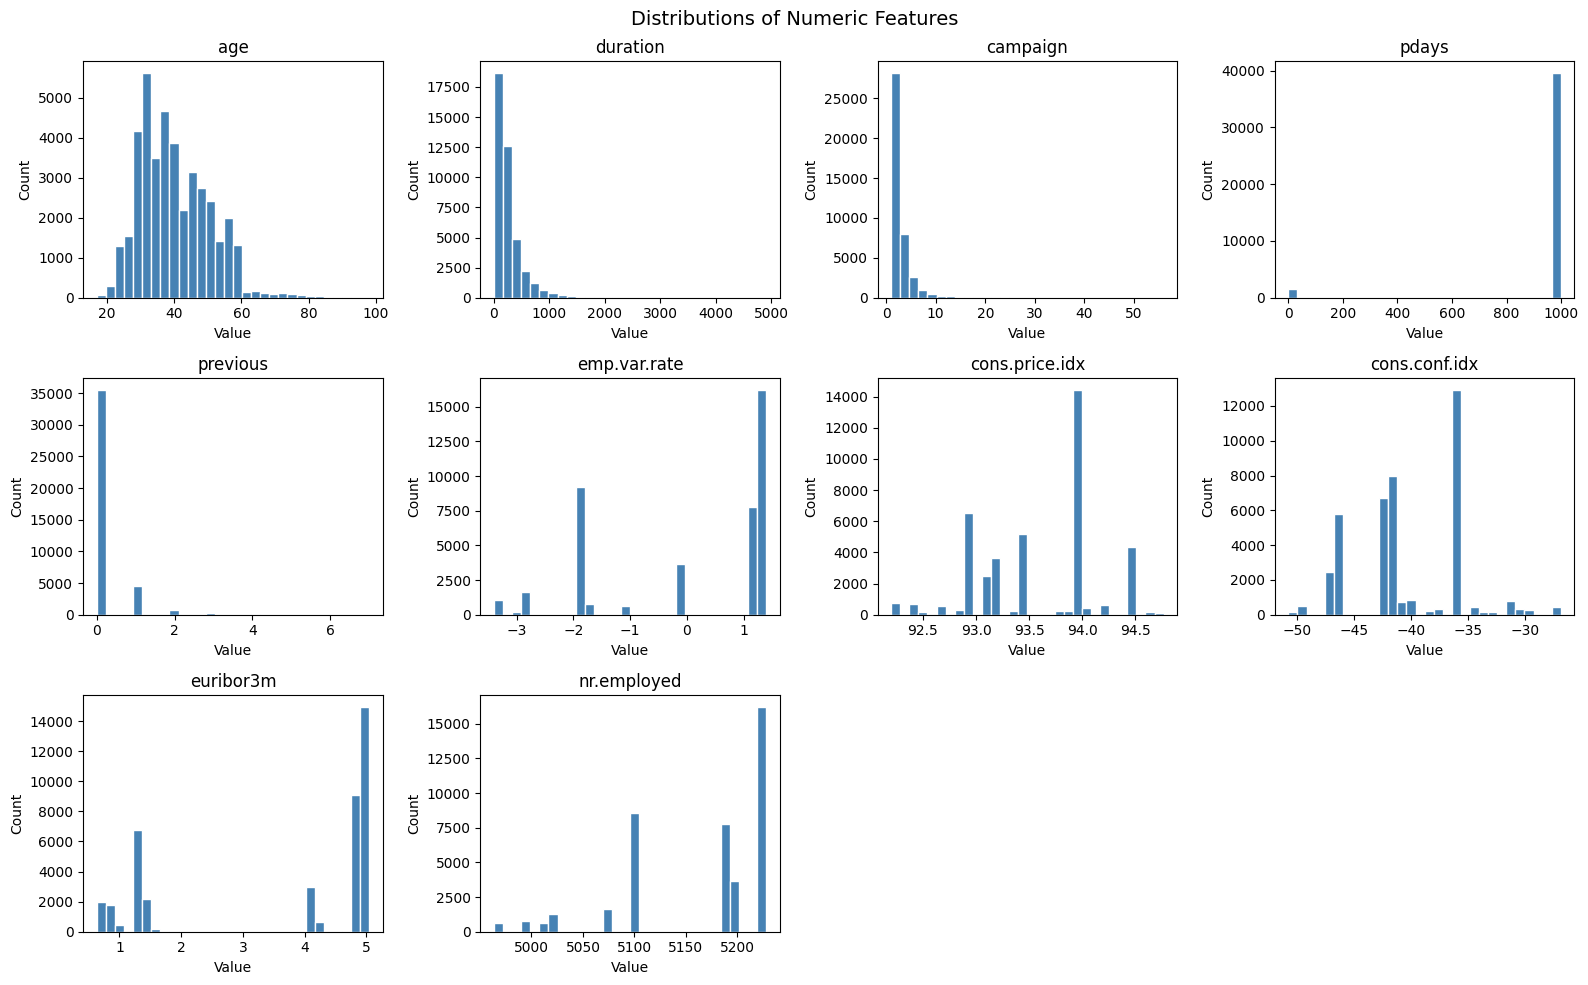

In [11]:
# Distributions of numeric features
print("=== Numeric Feature Statistics (min, max, mean, std, skewness) ===")
stats = df[numeric_features].describe().T
stats['skewness'] = df[numeric_features].skew()
print(stats)

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()
for i, col in enumerate(numeric_features):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Count")
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle("Distributions of Numeric Features", fontsize=14)
plt.tight_layout()
plt.show()

In [12]:
# Categorical feature counts + unknown value detection
print("=== Categorical Feature Value Counts ===\n")
for col in categorical_features:
    print(f"--- {col} ---")
    print(df[col].value_counts())
    print()

print("=== Unknown Value Counts ===")
for col in categorical_features:
    unknown_count = (df[col] == 'unknown').sum()
    if unknown_count > 0:
        print(f"  {col}: {unknown_count} unknowns ({unknown_count/len(df)*100:.1f}%)")

=== Categorical Feature Value Counts ===

--- job ---
job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64

--- marital ---
marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64

--- education ---
education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64

--- default ---
default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64

--- housing ---
housing
yes        21576
no         18622
unknown      990
Name: count, dtype: int64

--- loan ---
loan
no     

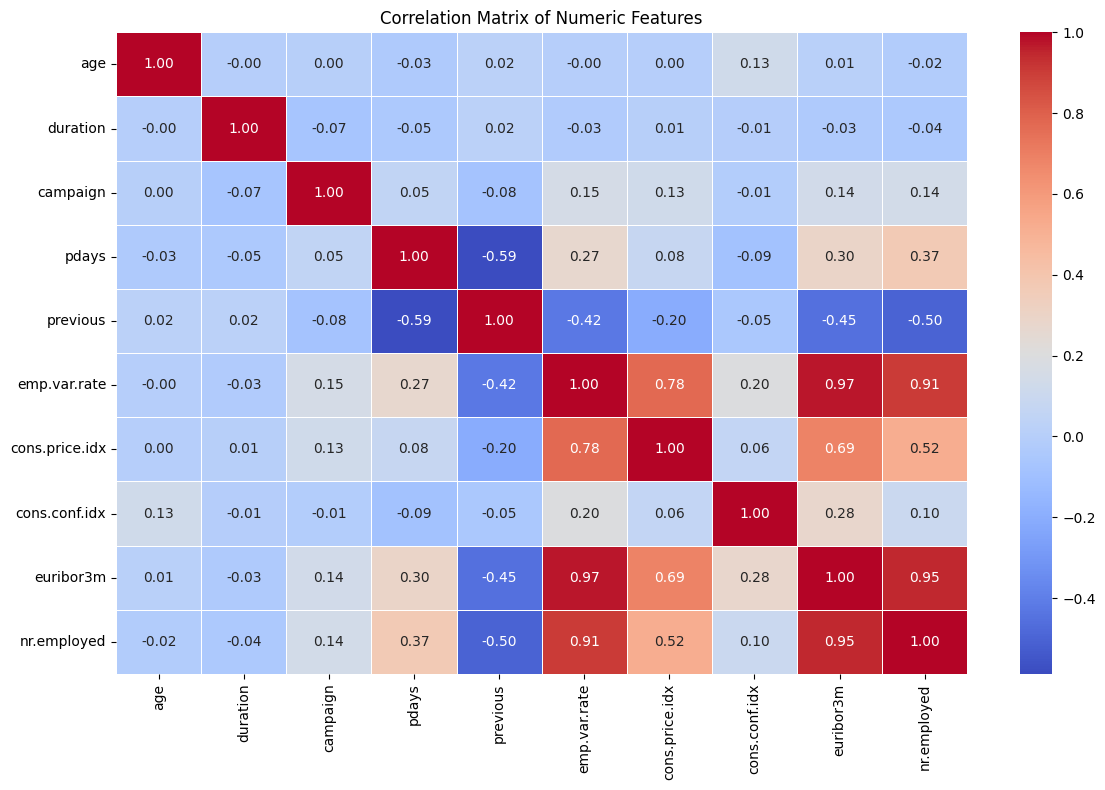

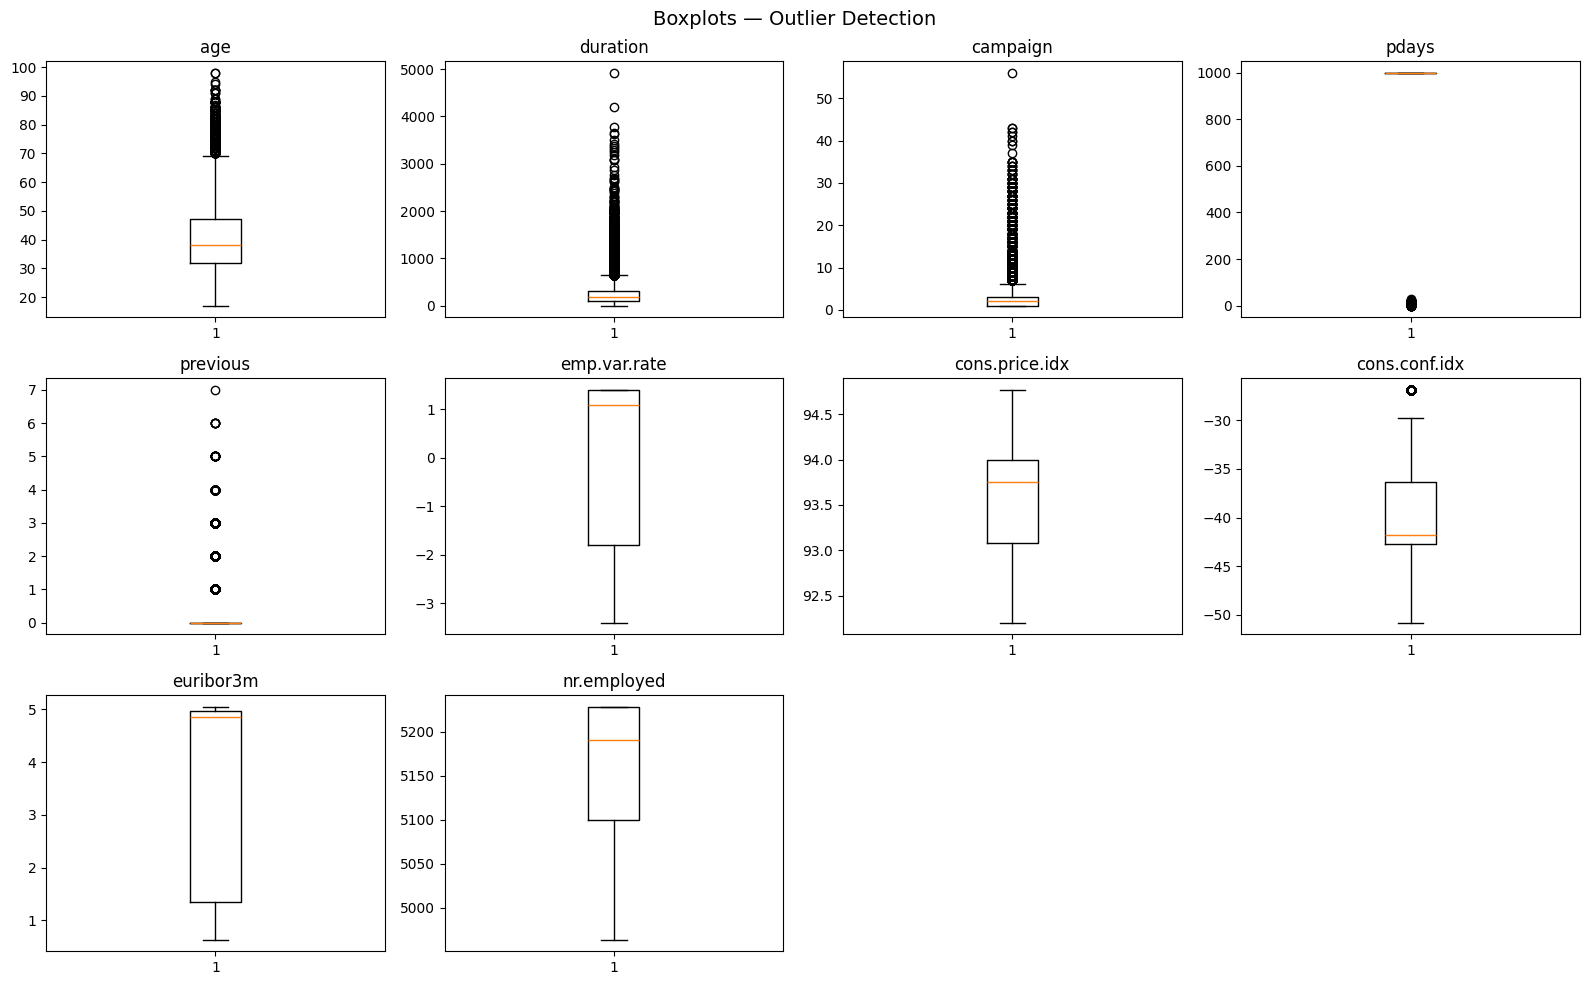

In [13]:
# Correlation matrix + outlier detection via boxplots
plt.figure(figsize=(12, 8))
corr = df[numeric_features].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Matrix of Numeric Features")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()
for i, col in enumerate(numeric_features):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(col)
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle("Boxplots — Outlier Detection", fontsize=14)
plt.tight_layout()
plt.show()

Data preparation

In [14]:
# Drop target column 'y' (we don't use labels in clustering)
# Drop 'duration' — only known after the call ends (unrealistic feature)
df_prep = df.drop(columns=['y', 'duration'])

print("Columns after dropping:", df_prep.columns.tolist())
print("Shape:", df_prep.shape)

Columns after dropping: ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
Shape: (41188, 19)


In [15]:
# Handle 'unknown' values — replace with the column's most frequent value (mode)
for col in df_prep.select_dtypes(include='object').columns:
    if (df_prep[col] == 'unknown').any():
        mode_val = df_prep[col][df_prep[col] != 'unknown'].mode()[0]
        df_prep[col] = df_prep[col].replace('unknown', mode_val)
        print(f"  Replaced 'unknown' in '{col}' with '{mode_val}'")

print("\nAny unknowns remaining?", (df_prep == 'unknown').any().any())

  Replaced 'unknown' in 'job' with 'admin.'
  Replaced 'unknown' in 'marital' with 'married'
  Replaced 'unknown' in 'education' with 'university.degree'
  Replaced 'unknown' in 'default' with 'no'
  Replaced 'unknown' in 'housing' with 'yes'
  Replaced 'unknown' in 'loan' with 'no'

Any unknowns remaining? False


In [16]:
# Encode categorical features using Label Encoding
le = LabelEncoder()
for col in df_prep.select_dtypes(include='object').columns:
    df_prep[col] = le.fit_transform(df_prep[col])

print("All features numeric:", df_prep.dtypes.unique())

# Scale all features with StandardScaler
# (K-Means uses distance — scaling ensures no feature dominates)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_prep)
X_scaled = pd.DataFrame(X_scaled, columns=df_prep.columns)

print("\nNo missing values?", not X_scaled.isnull().any().any())
print("Shape:", X_scaled.shape)
print(X_scaled.head())

All features numeric: [dtype('int64') dtype('float64')]

No missing values? True
Shape: (41188, 19)
        age      job   marital  education   default   housing      loan  \
0  1.533034 -0.17930 -0.279803  -1.780318 -0.008535 -1.100814 -0.422872   
1  1.628993  0.94758 -0.279803  -0.338826 -0.008535 -1.100814 -0.422872   
2 -0.290186  0.94758 -0.279803  -0.338826 -0.008535  0.908418 -0.422872   
3 -0.002309 -1.02446 -0.279803  -1.299821 -0.008535 -1.100814 -0.422872   
4  1.533034  0.94758 -0.279803  -0.338826 -0.008535 -1.100814  2.364781   

   contact     month  day_of_week  campaign     pdays  previous  poutcome  \
0  1.31827  0.762558    -0.718834 -0.565922  0.195414 -0.349494  0.192622   
1  1.31827  0.762558    -0.718834 -0.565922  0.195414 -0.349494  0.192622   
2  1.31827  0.762558    -0.718834 -0.565922  0.195414 -0.349494  0.192622   
3  1.31827  0.762558    -0.718834 -0.565922  0.195414 -0.349494  0.192622   
4  1.31827  0.762558    -0.718834 -0.565922  0.195414 -0.349494 

Apply K-Means

In [17]:
# Start with K=3 as initial guess
kmeans = KMeans(n_clusters=3, n_init=10, random_state=42)
labels = kmeans.fit_predict(X_scaled)

df['Cluster'] = labels

print("Cluster distribution:")
print(pd.Series(labels).value_counts().sort_index())

Cluster distribution:
0    26967
1    12705
2     1516
Name: count, dtype: int64


In [18]:
# View cluster centroids (scaled space)
centroids = pd.DataFrame(kmeans.cluster_centers_, columns=df_prep.columns)
print("=== Cluster Centroids (Scaled) ===")
print(centroids)

=== Cluster Centroids (Scaled) ===
        age       job   marital  education   default   housing      loan  \
0  0.013989 -0.008456 -0.064458  -0.022064  0.000156 -0.041582 -0.001199   
1 -0.050666  0.002268  0.113984   0.018843  0.000687  0.082017  0.002538   
2  0.175810  0.131410  0.191220   0.234538 -0.008535  0.052241  0.000057   

    contact     month  day_of_week  campaign     pdays  previous  poutcome  \
0  0.294714 -0.063467     0.027877  0.092888  0.195414 -0.348595  0.191396   
1 -0.553436  0.105591    -0.064909 -0.165045  0.195414  0.380452 -0.695949   
2 -0.603766  0.243951     0.048146 -0.268967 -5.113760  3.012003  2.428464   

   emp.var.rate  cons.price.idx  cons.conf.idx  euribor3m  nr.employed  
0      0.678938        0.491149       0.239592   0.700400     0.648054  
1     -1.275504       -0.994401      -0.564203  -1.305169    -1.147781  
2     -1.386342       -0.402026       0.466978  -1.519462    -1.907471  


In [19]:
# Cluster profiles in original scale
print("=== Cluster Profiles (Original Scale) ===")
print(df.groupby('Cluster')[numeric_features].mean().round(2))

=== Cluster Profiles (Original Scale) ===
           age  duration  campaign   pdays  previous  emp.var.rate  \
Cluster                                                              
0        40.17    253.43      2.82  999.00      0.00          1.15   
1        39.50    261.06      2.11  999.00      0.36         -1.92   
2        41.86    321.39      1.82    6.67      1.66         -2.10   

         cons.price.idx  cons.conf.idx  euribor3m  nr.employed  
Cluster                                                         
0                 93.86         -39.39       4.84      5213.86  
1                 93.00         -43.11       1.36      5084.10  
2                 93.34         -38.34       0.99      5029.22  


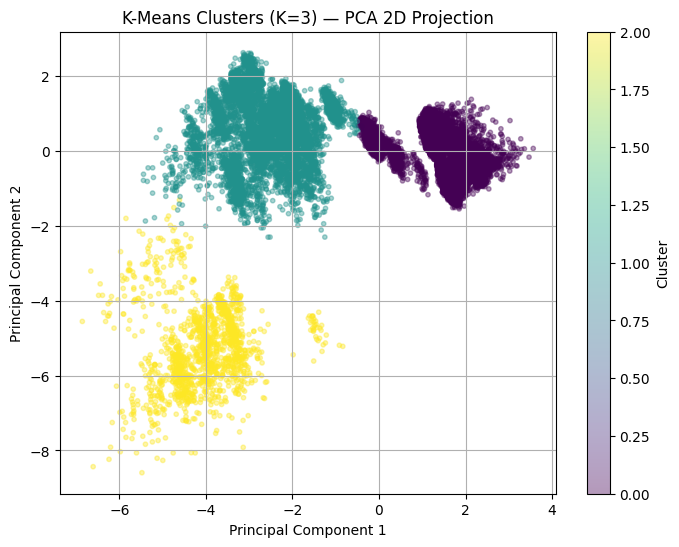

In [20]:
# Visualize clusters using PCA (reduce to 2D)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', alpha=0.4, s=10)
plt.colorbar(scatter, label='Cluster')
plt.title("K-Means Clusters (K=3) — PCA 2D Projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.show()

Choosing K

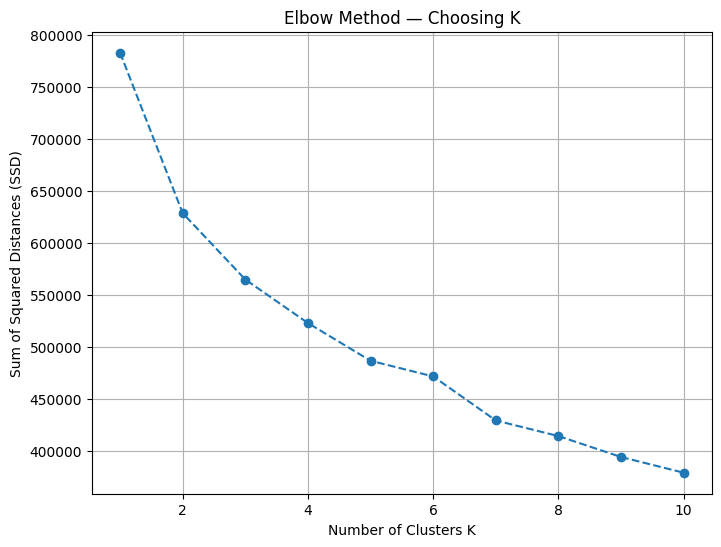

In [21]:
# Elbow Method: SSD vs K
ssd = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(X_scaled)
    ssd.append(km.inertia_)

plt.figure(figsize=(8, 6))
plt.plot(K_range, ssd, 'o--')
plt.xlabel("Number of Clusters K")
plt.ylabel("Sum of Squared Distances (SSD)")
plt.title("Elbow Method — Choosing K")
plt.grid(True)
plt.show()

K=2 → Silhouette Score: 0.2495
K=3 → Silhouette Score: 0.2527
K=4 → Silhouette Score: 0.1496
K=5 → Silhouette Score: 0.1650
K=6 → Silhouette Score: 0.1510
K=7 → Silhouette Score: 0.1686
K=8 → Silhouette Score: 0.1400
K=9 → Silhouette Score: 0.1513
K=10 → Silhouette Score: 0.1511


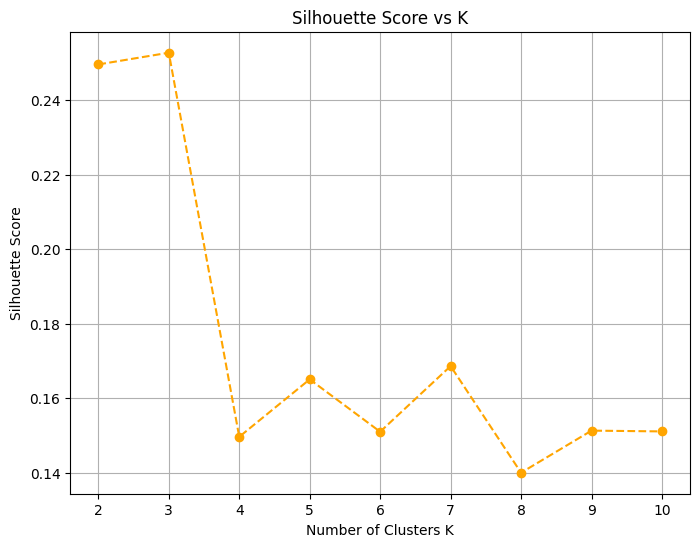

In [22]:
# Silhouette Scores for K=2 to 10
sil_scores = []

for k in range(2, 11):
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    cluster_labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, cluster_labels)
    sil_scores.append(score)
    print(f"K={k} → Silhouette Score: {score:.4f}")

plt.figure(figsize=(8, 6))
plt.plot(range(2, 11), sil_scores, 'o--', color='orange')
plt.xlabel("Number of Clusters K")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs K")
plt.grid(True)
plt.show()

In [23]:
# Select the best K based on highest Silhouette Score
best_k = sil_scores.index(max(sil_scores)) + 2  # +2 because range starts at 2
print(f"Best K by Silhouette Score: {best_k}")

# Retrain final model with best K
kmeans_final = KMeans(n_clusters=best_k, n_init=10, random_state=42)
final_labels = kmeans_final.fit_predict(X_scaled)

df['Cluster'] = final_labels

print("\nFinal Cluster distribution:")
print(pd.Series(final_labels).value_counts().sort_index())

Best K by Silhouette Score: 3

Final Cluster distribution:
0    26967
1    12705
2     1516
Name: count, dtype: int64


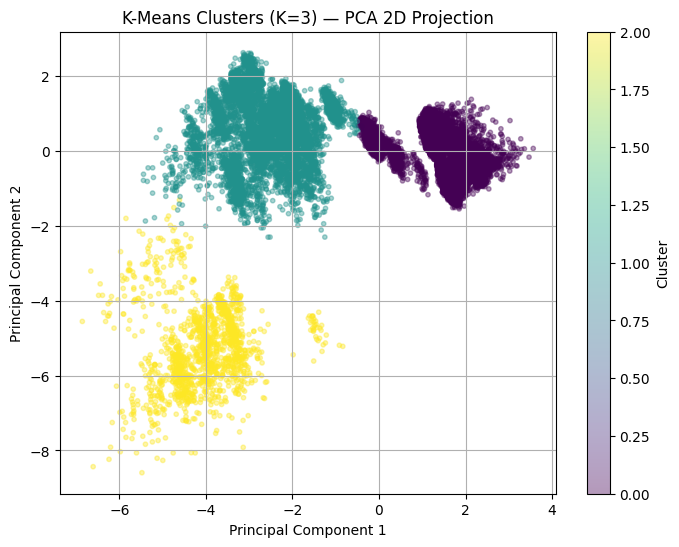


=== Final Cluster Profiles (Original Scale) ===
           age  duration  campaign   pdays  previous  emp.var.rate  \
Cluster                                                              
0        40.17    253.43      2.82  999.00      0.00          1.15   
1        39.50    261.06      2.11  999.00      0.36         -1.92   
2        41.86    321.39      1.82    6.67      1.66         -2.10   

         cons.price.idx  cons.conf.idx  euribor3m  nr.employed  
Cluster                                                         
0                 93.86         -39.39       4.84      5213.86  
1                 93.00         -43.11       1.36      5084.10  
2                 93.34         -38.34       0.99      5029.22  


In [24]:
# Final cluster visualization with best K
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=final_labels, cmap='viridis', alpha=0.4, s=10)
plt.colorbar(scatter, label='Cluster')
plt.title(f"K-Means Clusters (K={best_k}) — PCA 2D Projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.show()

print("\n=== Final Cluster Profiles (Original Scale) ===")
print(df.groupby('Cluster')[numeric_features].mean().round(2))